In [1]:
import folium
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# Load census tract data
census_tracts = gpd.read_file('Census 2020_ Tracts for San Francisco_20250320.geojson')

In [3]:

# Convert all date/time columns to strings to avoid serialization issues
for column in census_tracts.select_dtypes(include=['datetime', 'datetimetz']):
    census_tracts[column] = census_tracts[column].astype(str)

In [4]:
census_tracts

,name,intptlon,awater,mtfcc,aland,namelsad,tractce,statefp,data_loaded_at,intptlat,funcstat,countyfp,data_as_of,geoid,geometry
0,9805.01,-122.4193463,9769.0,G5020,1471536.0,Census Tract 9805.01,980501,06,2022-03-04,+37.7162081,S,075,2021-02-01,06075980501,"MULTIPOLYGON (((-122.42722 37.71555, -122.4271..."
1,171.02,-122.4504754,0.0,G5020,294894.0,Census Tract 171.02,017102,06,2022-03-04,+37.7654353,S,075,2021-02-01,06075017102,"MULTIPOLYGON (((-122.45321 37.76825, -122.4516..."
2,123.02,-122.4120970,0.0,G5020,92653.0,Census Tract 123.02,012302,06,2022-03-04,+37.7870222,S,075,2021-02-01,06075012302,"MULTIPOLYGON (((-122.415 37.78745, -122.41335 ..."
3,168.01,-122.4290133,0.0,G5020,226534.0,Census Tract 168.01,016801,06,2022-03-04,+37.7713309,S,075,2021-02-01,06075016801,"MULTIPOLYGON (((-122.43235 37.77378, -122.4308..."
4,119.02,-122.4098067,0.0,G5020,93053.0,Census Tract 119.02,011902,06,2022-03-04,+37.7909959,S,075,2021-02-01,06075011902,"MULTIPOLYGON (((-122.41246 37.79163, -122.4117..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
239,202.01,-122.4240946,0.0,G5020,140617.0,Census Tract 202.01,020201,06,2022-03-04,+37.7647879,S,075,2021-02-01,06075020201,"MULTIPOLYGON (((-122.42646 37.76627, -122.4252..."
240,615.08,-122.3863814,152297.0,G5020,227943.0,Census Tract 615.08,061508,06,2022-03-04,+37.7857520,S,075,2021-02-01,06075061508,"MULTIPOLYGON (((-122.39362 37.78308, -122.3928..."
241,130.01,-122.4272277,0.0,G5020,181456.0,Census Tract 130.01,013001,06,2022-03-04,+37.7976627,S,075,2021-02-01,06075013001,"MULTIPOLYGON (((-122.43075 37.79865, -122.4291..."
242,102.01,-122.4212147,0.0,G5020,186873.0,Census Tract 102.01,010201,06,2022-03-04,+37.8013029,S,075,2021-02-01,06075010201,"MULTIPOLYGON (((-122.42484 37.80227, -122.4246..."


In [5]:
# Create a map centered around San Francisco
sf_location = [37.7749, -122.4194]
m = folium.Map(location=sf_location, zoom_start=12)

In [6]:
# Add census tracts to the map
folium.GeoJson(
    census_tracts,
    style_function=lambda feature: {
        'fillColor': '#FFEDA0',
        'color': 'white',
        'weight': 2,
        'dashArray': '3',
        'fillOpacity': 0.7,
    }
).add_to(m)

In [7]:
m

In [8]:
data = pd.read_csv("bus_stops_with_tracts.csv")

In [9]:
data

,STOPID,STOPNAME,LATITUDE,School Name,LONGITUDE,time_difference,route_id,NAMELSAD
0,5351,Mansell St&Somerset St S-NS/PS,37.720418,"Burton, Phillip And Sala Burton High School",-122.405094,0 days 00:00:27.318181818,29,Census Tract 259
1,5351,Mansell St&Somerset St S-NS/PS,37.720418,"Burton, Phillip And Sala Burton High School",-122.405094,0 days 00:01:40,56,Census Tract 259
2,5351,Mansell St&Somerset St S-NS/PS,37.720418,"Burton, Phillip And Sala Burton High School",-122.405094,0 days 00:00:13.772727272,29,Census Tract 259
3,5351,Mansell St&Somerset St S-NS/PS,37.720418,"Burton, Phillip And Sala Burton High School",-122.405094,0 days 00:01:04,56,Census Tract 259
4,5351,Mansell St&Somerset St S-NS/PS,37.720418,"Burton, Phillip And Sala Burton High School",-122.405094,0 days 00:00:28,56,Census Tract 259
...,...,...,...,...,...,...,...,...
3077,3603,46th Ave&Vicente St SE-NS/PS,37.737973,"Washington, George Washington High School",-122.504268,0 days 00:19:43,18,Census Tract 354
3078,3603,46th Ave&Vicente St SE-NS/PS,37.737973,"Washington, George Washington High School",-122.504268,0 days 00:21:19,18,Census Tract 354
3079,6732,Turk St&Stanyan St SE-FS/BZ,37.777557,Gateway High School / Kipp Sf Bay Academy,-122.455035,0 days 00:06:20.333333333,31,Census Tract 157.01
3080,6732,Turk St&Stanyan St SE-FS/BZ,37.777557,Gateway High School / Kipp Sf Bay Academy,-122.455035,0 days 00:07:31.833333333,31,Census Tract 157.01


In [105]:
df_unique = data.drop_duplicates(subset='STOPID', keep='first')

In [106]:
df_unique

,STOPID,STOPNAME,LATITUDE,School Name,LONGITUDE,time_difference,route_id,NAMELSAD
0,5351,Mansell St&Somerset St S-NS/PS,37.720418,"Burton, Phillip And Sala Burton High School",-122.405094,0 min 27 sec,29,Census Tract 259
5,4783,Gilman Ave&3rd St E-NS/PS,37.722458,"Burton, Phillip And Sala Burton High School",-122.395415,4 min 6 sec,29,Census Tract 234
10,3071,Balboa St&Park Presidio Blvd SW-NS,37.776788,Gateway High School / Kipp Sf Bay Academy,-122.472411,11 min 51 sec,31,Census Tract 476
13,5274,Lombard St&Fillmore St SE-FS/BZ,37.799818,Galileo High School,-122.435878,7 min 3 sec,28,Census Tract 129.02
17,4329,Castro St&25TH St SE-NS/BZ,37.749600,Gateway High School / Kipp Sf Bay Academy,-122.433830,15 min 46 sec,24,Census Tract 214
...,...,...,...,...,...,...,...,...
3066,6609,Sutter St&Steiner St NE-NS/BZ,37.785942,Gateway High School / Kipp Sf Bay Academy,-122.434793,1 min 57 sec,2,Census Tract 152.02
3068,5633,Galvez Ave&Hill Ave MB-NS/BZ,37.728795,Galileo High School,-122.367027,53 min 8 sec,19,Census Tract 9806
3073,7979,Moscow St&Geneva Ave S-FS/BZ,37.713233,"Burton, Phillip And Sala Burton High School",-122.433557,11 min 38 sec,54,Census Tract 263.02
3075,3603,46th Ave&Vicente St SE-NS/PS,37.737973,"Washington, George Washington High School",-122.504268,19 min 18 sec,18,Census Tract 354


In [124]:
# Create DataFrame with unique STOPID values
unique_stop_ids_df = pd.DataFrame(unique_stop_ids, columns=['Unique STOPID'])

In [125]:

# Group by NAMELSAD and count unique school names
unique_school_counts = data.groupby('NAMELSAD')['School Name'].nunique().reset_index()

In [11]:
# Sort the census tracts based on the number of unique schools in descending order
sorted_unique_school_counts = unique_school_counts.sort_values(by='School Name', ascending=False)

In [12]:
sorted_unique_school_counts

,NAMELSAD,School Name
15,Census Tract 117,3
27,Census Tract 124.06,3
31,Census Tract 126.02,3
34,Census Tract 128.02,3
36,Census Tract 129.02,3
...,...,...
164,Census Tract 611.01,1
171,Census Tract 615.03,1
170,Census Tract 615.02,1
174,Census Tract 9805.01,1


In [13]:
# Find the largest time difference for each school
largest_time_difference = data.groupby('School Name')['time_difference'].max().reset_index()
largest_time_difference.columns = ['School Name', 'Largest Time Difference']

In [14]:

# Sort the data by the largest time difference from largest to shortest
sorted_largest_time_difference = largest_time_difference.sort_values(by='Largest Time Difference', ascending=False)

In [15]:
sorted_largest_time_difference 

,School Name,Largest Time Difference
0,"Burton, Phillip And Sala Burton High School",0 days 00:56:16
1,Galileo High School,0 days 00:53:08.571428571
4,"Washington, George Washington High School",0 days 00:49:48
2,Gateway High School / Kipp Sf Bay Academy,0 days 00:42:55.384615384
3,"Lincoln, Abraham Lincoln High School",0 days 00:40:55.833333333


In [16]:
# Function to convert time difference to minutes and seconds
def convert_time_difference(time_diff):
    days, time_str = time_diff.split(' days ')
    hours, minutes, seconds = map(float, time_str.split(':'))
    total_seconds = hours * 3600 + minutes * 60 + seconds
    minutes, seconds = divmod(total_seconds, 60)
    return f'{int(minutes)} min {int(seconds)} sec'

In [17]:
# Convert time differences to minutes and seconds
data['time_difference'] = data['time_difference'].apply(convert_time_difference)

In [18]:
# Filter stops data to keep only unique route IDs per NAMELSAD
stops_data_unique = data.drop_duplicates(subset=['NAMELSAD', 'route_id'])

In [19]:
# Group by NAMELSAD to handle multiple routes and school names
grouped_stops = stops_data_unique.groupby('NAMELSAD').agg({
    'route_id': lambda x: ', '.join(x.astype(str)),
     'School Name': lambda x: ', '.join(x.drop_duplicates()),
    'time_difference': lambda x: ', '.join(x.drop_duplicates())
}).reset_index()

In [20]:
# Merge the data based on the NAMELSAD field
merged_data = census_tracts.merge(grouped_stops, left_on='namelsad', right_on='NAMELSAD')

In [21]:
merged_data

,name,intptlon,awater,mtfcc,aland,namelsad,tractce,statefp,data_loaded_at,intptlat,funcstat,countyfp,data_as_of,geoid,geometry,NAMELSAD,route_id,School Name,time_difference
0,9805.01,-122.4193463,9769.0,G5020,1471536.0,Census Tract 9805.01,980501,06,2022-03-04,+37.7162081,S,075,2021-02-01,06075980501,"MULTIPOLYGON (((-122.42722 37.71555, -122.4271...",Census Tract 9805.01,"29, 56, 54","Burton, Phillip And Sala Burton High School","3 min 32 sec, 2 min 37 sec, 0 min 51 sec"
1,123.02,-122.4120970,0.0,G5020,92653.0,Census Tract 123.02,012302,06,2022-03-04,+37.7870222,S,075,2021-02-01,06075012302,"MULTIPOLYGON (((-122.415 37.78745, -122.41335 ...",Census Tract 123.02,"38, 38R","Washington, George Washington High School","36 min 2 sec, 29 min 0 sec"
2,168.01,-122.4290133,0.0,G5020,226534.0,Census Tract 168.01,016801,06,2022-03-04,+37.7713309,S,075,2021-02-01,06075016801,"MULTIPOLYGON (((-122.43235 37.77378, -122.4308...",Census Tract 168.01,22,Gateway High School / Kipp Sf Bay Academy,10 min 2 sec
3,122.02,-122.4196803,0.0,G5020,94685.0,Census Tract 122.02,012202,06,2022-03-04,+37.7854270,S,075,2021-02-01,06075012202,"MULTIPOLYGON (((-122.42168 37.7866, -122.42146...",Census Tract 122.02,"19, 38, 49","Galileo High School, Washington, George Washin...","12 min 45 sec, 33 min 39 sec, 8 min 8 sec"
4,126.01,-122.4391509,0.0,G5020,170458.0,Census Tract 126.01,012601,06,2022-03-04,+37.8022683,S,075,2021-02-01,06075012601,"MULTIPOLYGON (((-122.4419 37.80374, -122.44103...",Census Tract 126.01,22,Gateway High School / Kipp Sf Bay Academy,10 min 40 sec
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
172,128.02,-122.4385354,0.0,G5020,199611.0,Census Tract 128.02,012802,06,2022-03-04,+37.7983583,S,075,2021-02-01,06075012802,"MULTIPOLYGON (((-122.44118 37.80019, -122.4403...",Census Tract 128.02,"30, 28, 22","Galileo High School, Lincoln, Abraham Lincoln ...","4 min 23 sec, 23 min 40 sec, 7 min 40 sec"
173,130.02,-122.4337546,0.0,G5020,184367.0,Census Tract 130.02,013002,06,2022-03-04,+37.7968323,S,075,2021-02-01,06075013002,"MULTIPOLYGON (((-122.43733 37.79781, -122.4356...",Census Tract 130.02,22,Gateway High School / Kipp Sf Bay Academy,8 min 27 sec
174,206.01,-122.4300824,0.0,G5020,321062.0,Census Tract 206.01,020601,06,2022-03-04,+37.7609052,S,075,2021-02-01,06075020601,"MULTIPOLYGON (((-122.43519 37.76267, -122.4349...",Census Tract 206.01,24,Gateway High School / Kipp Sf Bay Academy,11 min 6 sec
175,102.01,-122.4212147,0.0,G5020,186873.0,Census Tract 102.01,010201,06,2022-03-04,+37.8013029,S,075,2021-02-01,06075010201,"MULTIPOLYGON (((-122.42484 37.80227, -122.4246...",Census Tract 102.01,19,Galileo High School,3 min 17 sec


In [22]:
# Function to style the census tracts
def style_function(feature):
    return {
        'fillColor': '#FFEDA0',
        'color': 'white',
        'weight': 2,
        'dashArray': '3',
        'fillOpacity': 0.7,
    }

In [23]:

# Function to create tooltips
def create_tooltip(row):
    tooltip_text = f"Route ID: {row['route_id']}<br>"
    tooltip_text += f"School Name: {row['School Name']}<br>"
    tooltip_text += f"Time Difference: {row['time_difference']}<br>"
    tooltip_text += f"Census Tract: {row['NAMELSAD']}<br>"
    return tooltip_text

# Add census tracts to the map along with tooltips
for _, row in merged_data.iterrows():
    geo_json = folium.GeoJson(
        row.geometry,
        style_function=lambda x: {'fillColor': 'green', 'color': 'green', 'weight': 1}
    )
    tooltip = folium.Tooltip(create_tooltip(row))
    geo_json.add_child(tooltip)
    geo_json.add_to(m)

In [24]:
m


In [25]:
# Save the map to an HTML file
m.save('census_tract_map.html')

In [26]:

# Filter for census tracts with exactly 3 unique school names
tracts_with_3_schools = sorted_unique_school_counts[sorted_unique_school_counts['School Name'] == 3]

In [27]:
# Create a map centered around San Francisco
sf_location = [37.7749, -122.4194]
m2 = folium.Map(location=sf_location, zoom_start=12)

In [28]:
# Add census tracts to the map
folium.GeoJson(
    census_tracts,
    style_function=lambda feature: {
        'fillColor': '#FFEDA0',
        'color': 'white',
        'weight': 2,
        'dashArray': '3',
        'fillOpacity': 0.7,
    }
).add_to(m2)

In [29]:
# Merge the data based on the NAMELSAD field
merged_data = census_tracts.merge(tracts_with_3_schools, left_on='namelsad', right_on='NAMELSAD')

In [30]:
# Function to style the census tracts
def style_function(feature):
    return {
        'fillColor': '#FFEDA0',
        'color': 'white',
        'weight': 2,
        'dashArray': '3',
        'fillOpacity': 0.7,
    }

In [31]:
# Function to create tooltips
def create_tooltip(row):
    tooltip_text = f"Census Tract: {row['namelsad']}<br>"
    tooltip_text += f"Number of Unique School Names: {row['School Name']}<br>"
    return tooltip_text

In [32]:

# Add census tracts to the map along with tooltips
for _, row in merged_data.iterrows():
    geo_json = folium.GeoJson(
        row.geometry,
        style_function=lambda x: {'fillColor': 'green', 'color': 'green', 'weight': 1}
    )
    tooltip = folium.Tooltip(create_tooltip(row))
    geo_json.add_child(tooltip)
    geo_json.add_to(m2)


In [33]:
# Save the map to an HTML file
m2.save('census_tract_map_exact_3_schools.html')

In [34]:

# Filter for census tracts with exactly 3 unique school names
tracts_with_2_schools = sorted_unique_school_counts[sorted_unique_school_counts['School Name'] == 2]

In [35]:
# Create a map centered around San Francisco
sf_location = [37.7749, -122.4194]
m3 = folium.Map(location=sf_location, zoom_start=12)

In [36]:
# Add census tracts to the map
folium.GeoJson(
    census_tracts,
    style_function=lambda feature: {
        'fillColor': '#FFEDA0',
        'color': 'white',
        'weight': 2,
        'dashArray': '3',
        'fillOpacity': 0.7,
    }
).add_to(m3)

In [37]:
# Merge the data based on the NAMELSAD field
merged_data = census_tracts.merge(tracts_with_2_schools, left_on='namelsad', right_on='NAMELSAD')

In [38]:
# Function to style the census tracts
def style_function(feature):
    return {
        'fillColor': '#FFEDA0',
        'color': 'white',
        'weight': 2,
        'dashArray': '3',
        'fillOpacity': 0.7,
    }

In [39]:
# Function to create tooltips
def create_tooltip(row):
    tooltip_text = f"Census Tract: {row['namelsad']}<br>"
    tooltip_text += f"Number of Unique School Names: {row['School Name']}<br>"
    return tooltip_text

In [40]:

# Add census tracts to the map along with tooltips
for _, row in merged_data.iterrows():
    geo_json = folium.GeoJson(
        row.geometry,
        style_function=lambda x: {'fillColor': 'green', 'color': 'green', 'weight': 1}
    )
    tooltip = folium.Tooltip(create_tooltip(row))
    geo_json.add_child(tooltip)
    geo_json.add_to(m3)


In [41]:
# Save the map to an HTML file
m3.save('census_tract_map_exact_2_schools.html')

In [42]:

# Filter for census tracts with exactly 3 unique school names
tracts_with_23_schools = sorted_unique_school_counts[sorted_unique_school_counts['School Name'] == 1]

In [43]:
# Create a map centered around San Francisco
sf_location = [37.7749, -122.4194]
m4 = folium.Map(location=sf_location, zoom_start=12)

In [44]:
# Add census tracts to the map
folium.GeoJson(
    census_tracts,
    style_function=lambda feature: {
        'fillColor': '#FFEDA0',
        'color': 'white',
        'weight': 2,
        'dashArray': '3',
        'fillOpacity': 0.7,
    }
).add_to(m4)

In [45]:
# Merge the data based on the NAMELSAD field
merged_data = census_tracts.merge(tracts_with_23_schools, left_on='namelsad', right_on='NAMELSAD')

In [46]:
# Function to style the census tracts
def style_function(feature):
    return {
        'fillColor': '#FFEDA0',
        'color': 'white',
        'weight': 2,
        'dashArray': '3',
        'fillOpacity': 0.7,
    }

In [47]:
# Function to create tooltips
def create_tooltip(row):
    tooltip_text = f"Census Tract: {row['namelsad']}<br>"
    tooltip_text += f"Number of Unique School Names: {row['School Name']}<br>"
    return tooltip_text

In [48]:

# Add census tracts to the map along with tooltips
for _, row in merged_data.iterrows():
    geo_json = folium.GeoJson(
        row.geometry,
        style_function=lambda x: {'fillColor': 'green', 'color': 'green', 'weight': 1}
    )
    tooltip = folium.Tooltip(create_tooltip(row))
    geo_json.add_child(tooltip)
    geo_json.add_to(m4)


In [49]:
# Save the map to an HTML file
m4.save('census_tract_map_exact_1_schools.html')

In [50]:
# Filter for census tracts with exactly 2 or 3 unique school names
tracts_with_2_or_3_schools = sorted_unique_school_counts[sorted_unique_school_counts['School Name'].isin([2, 3])]

In [51]:
# Create a map centered around San Francisco
sf_location = [37.7749, -122.4194]
m5 = folium.Map(location=sf_location, zoom_start=12)

In [52]:
# Add census tracts to the map
folium.GeoJson(
    census_tracts,
    style_function=lambda feature: {
        'fillColor': '#FFEDA0',
        'color': 'white',
        'weight': 2,
        'dashArray': '3',
        'fillOpacity': 0.7,
    }
).add_to(m5)

In [53]:
# Merge the data based on the NAMELSAD field
merged_data = census_tracts.merge(tracts_with_2_or_3_schools, left_on='namelsad', right_on='NAMELSAD')

In [54]:
# Function to style the census tracts
def style_function(feature):
    return {
        'fillColor': '#FFEDA0',
        'color': 'white',
        'weight': 2,
        'dashArray': '3',
        'fillOpacity': 0.7,
    }

In [55]:
# Function to create tooltips
def create_tooltip(row):
    tooltip_text = f"Census Tract: {row['namelsad']}<br>"
    tooltip_text += f"Number of Unique School Names: {row['School Name']}<br>"
    return tooltip_text

In [56]:

# Add census tracts to the map along with tooltips
for _, row in merged_data.iterrows():
    geo_json = folium.GeoJson(
        row.geometry,
        style_function=lambda x: {'fillColor': 'green', 'color': 'green', 'weight': 1}
    )
    tooltip = folium.Tooltip(create_tooltip(row))
    geo_json.add_child(tooltip)
    geo_json.add_to(m5)


In [57]:
# Save the map to an HTML file
m5.save('census_tract_map_2 or 3_schools.html')

In [107]:
unique_stop_ids_df 

,Unique STOPID
0,5351
1,4783
2,3071
3,5274
4,4329
...,...
788,6609
789,5633
790,7979
791,3603


In [108]:
# Group by 'School Name' and get all the route IDs associated with each school
grouped = df_unique.groupby('School Name')['route_id'].apply(lambda x: list(set(x))).reset_index()

In [109]:
grouped

,School Name,route_id
0,"Burton, Phillip And Sala Burton High School","[29, 54, 56]"
1,Galileo High School,"[19, 49, 28, 30]"
2,Gateway High School / Kipp Sf Bay Academy,"[24, 38, 2, 22, 31]"
3,"Lincoln, Abraham Lincoln High School","[66, 28, 48]"
4,"Washington, George Washington High School","[38, 1, 18, 38R, 31]"


In [63]:
stops_data_unique.to_csv('results.csv', index=False)

In [110]:
# Count the number of bus stops in each census tract
bus_access_counts = df_unique['NAMELSAD'].value_counts()

In [111]:
busestracts = set(census_tracts['namelsad'].unique())

In [112]:
busestracts

{'Census Tract 101.01',
 'Census Tract 101.02',
 'Census Tract 102.01',
 'Census Tract 102.02',
 'Census Tract 103',
 'Census Tract 104.01',
 'Census Tract 104.02',
 'Census Tract 105',
 'Census Tract 106',
 'Census Tract 107.01',
 'Census Tract 107.02',
 'Census Tract 108',
 'Census Tract 109.01',
 'Census Tract 109.02',
 'Census Tract 110.01',
 'Census Tract 110.02',
 'Census Tract 111.01',
 'Census Tract 111.02',
 'Census Tract 112',
 'Census Tract 113',
 'Census Tract 117',
 'Census Tract 118',
 'Census Tract 119.01',
 'Census Tract 119.02',
 'Census Tract 120.01',
 'Census Tract 120.02',
 'Census Tract 121',
 'Census Tract 122.02',
 'Census Tract 122.03',
 'Census Tract 122.04',
 'Census Tract 123.01',
 'Census Tract 123.02',
 'Census Tract 124.03',
 'Census Tract 124.04',
 'Census Tract 124.05',
 'Census Tract 124.06',
 'Census Tract 125.02',
 'Census Tract 125.03',
 'Census Tract 125.04',
 'Census Tract 126.01',
 'Census Tract 126.02',
 'Census Tract 127',
 'Census Tract 128.01'

In [113]:
tracts_with_bus_access = set(bus_access_counts.index)

In [114]:
tracts_without_bus_access = busestracts - tracts_with_bus_access

In [115]:
tracts_without_bus_access 

{'Census Tract 103',
 'Census Tract 104.02',
 'Census Tract 107.01',
 'Census Tract 108',
 'Census Tract 109.01',
 'Census Tract 119.01',
 'Census Tract 119.02',
 'Census Tract 123.01',
 'Census Tract 125.04',
 'Census Tract 130.01',
 'Census Tract 154.02',
 'Census Tract 160',
 'Census Tract 161.02',
 'Census Tract 162',
 'Census Tract 165',
 'Census Tract 166.01',
 'Census Tract 166.02',
 'Census Tract 168.02',
 'Census Tract 170',
 'Census Tract 171.01',
 'Census Tract 171.02',
 'Census Tract 176.03',
 'Census Tract 178.03',
 'Census Tract 179.03',
 'Census Tract 202.01',
 'Census Tract 202.02',
 'Census Tract 204.01',
 'Census Tract 204.02',
 'Census Tract 205',
 'Census Tract 207.01',
 'Census Tract 207.02',
 'Census Tract 216',
 'Census Tract 218',
 'Census Tract 226',
 'Census Tract 227.02',
 'Census Tract 228.01',
 'Census Tract 228.03',
 'Census Tract 231.02',
 'Census Tract 254.02',
 'Census Tract 255.01',
 'Census Tract 257.01',
 'Census Tract 260.04',
 'Census Tract 262.01'

In [116]:
# Convert to DataFrame
tracts_without_bus_access_df = pd.DataFrame(list(tracts_without_bus_access), columns=['NAMELSAD'])

In [117]:
tracts_without_bus_access_df

,NAMELSAD
0,Census Tract 327
1,Census Tract 226
2,Census Tract 161.02
3,Census Tract 176.03
4,Census Tract 605.02
...,...
62,Census Tract 615.06
63,Census Tract 216
64,Census Tract 262.01
65,Census Tract 231.02


In [76]:
# Count the number of stops for each school
school_stop_counts = stops_data_unique['School Name'].value_counts().reset_index()
school_stop_counts.columns = ['School Name', 'Stop Count']

In [77]:
school_stop_counts

,School Name,Stop Count
0,"Washington, George Washington High School",80
1,Galileo High School,73
2,Gateway High School / Kipp Sf Bay Academy,69
3,"Burton, Phillip And Sala Burton High School",47
4,"Lincoln, Abraham Lincoln High School",45


In [78]:
streetlights = pd.read_csv('streetlights2.csv')

In [79]:
streetlights

,df_index,df2_index,df_coordinates,df2_coordinates,latitude,longitude,df2_latitude,df2_longitude
0,8,4280,"(37.71129, -122.45913)","(np.float64(37.71126631015692), np.float64(-12...",37.711290,-122.459130,37.711266,-122.459129
1,14,1501,"(37.800408, -122.447447)","(np.float64(37.800409938887206), np.float64(-1...",37.800408,-122.447447,37.800410,-122.447470
2,16,22442,"(37.782835, -122.414217)","(np.float64(37.78285086963361), np.float64(-12...",37.782835,-122.414217,37.782851,-122.414198
3,22,843,"(37.75299, -122.40669)","(np.float64(37.753008999086894), np.float64(-1...",37.752990,-122.406690,37.753009,-122.406654
4,38,14349,"(37.78849, -122.40248)","(np.float64(37.7885159705333), np.float64(-122...",37.788490,-122.402480,37.788516,-122.402498
...,...,...,...,...,...,...,...,...
104,772,2750,"(37.71128, -122.46198)","(np.float64(37.71124664999957), np.float64(-12...",37.711280,-122.461980,37.711247,-122.462007
105,774,17000,"(37.79242, -122.4142)","(np.float64(37.79243471875842), np.float64(-12...",37.792420,-122.414200,37.792435,-122.414234
106,777,18350,"(37.764762, -122.401516)","(np.float64(37.76473165309867), np.float64(-12...",37.764762,-122.401516,37.764732,-122.401494
107,787,11656,"(37.735796, -122.392175)","(np.float64(37.73578810175916), np.float64(-12...",37.735796,-122.392175,37.735788,-122.392184


In [131]:
# Merge the dataframes based on latitude and longitude
merged_df = pd.merge(df_unique, streetlights, left_on=['LATITUDE', 'LONGITUDE'], right_on=['latitude', 'longitude'])



In [132]:
merged_df

,STOPID,STOPNAME,LATITUDE,School Name,LONGITUDE,time_difference,route_id,NAMELSAD,df_index,df2_index,df_coordinates,df2_coordinates,latitude,longitude,df2_latitude,df2_longitude
0,6323,Sagamore St&Capitol Ave SW-NS,37.711290,"Burton, Phillip And Sala Burton High School",-122.459130,24 min 39 sec,54,Census Tract 314.01,8,4280,"(37.71129, -122.45913)","(np.float64(37.71126631015692), np.float64(-12...",37.711290,-122.459130,37.711266,-122.459129
1,6181,Richardson Ave&Francisco St NW-NS,37.800408,Galileo High School,-122.447447,9 min 3 sec,28,Census Tract 127,14,1501,"(37.800408, -122.447447)","(np.float64(37.800409938887206), np.float64(-1...",37.800408,-122.447447,37.800410,-122.447470
2,6721,Turk St&Leavenworth St NW-FS/BZ,37.782835,"Washington, George Washington High School",-122.414217,26 min 4 sec,31,Census Tract 124.04,16,22442,"(37.782835, -122.414217)","(np.float64(37.78285086963361), np.float64(-12...",37.782835,-122.414217,37.782851,-122.414198
3,3480,24th St&Potrero Ave NW-FS/BZ,37.752990,"Lincoln, Abraham Lincoln High School",-122.406690,29 min 24 sec,48,Census Tract 229.03,22,843,"(37.75299, -122.40669)","(np.float64(37.753008999086894), np.float64(-1...",37.752990,-122.406690,37.753009,-122.406654
4,5684,Market St&Montgomery St W-FS/BZ,37.788490,"Washington, George Washington High School",-122.402480,41 min 49 sec,38,Census Tract 117,38,14349,"(37.78849, -122.40248)","(np.float64(37.7885159705333), np.float64(-122...",37.788490,-122.402480,37.788516,-122.402498
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
104,6324,Sagamore St&Orizaba Ave SE-FS,37.711280,"Burton, Phillip And Sala Burton High School",-122.461980,25 min 54 sec,54,Census Tract 314.01,772,2750,"(37.71128, -122.46198)","(np.float64(37.71124664999957), np.float64(-12...",37.711280,-122.461980,37.711247,-122.462007
105,6301,Sacramento St&Jones St NE-NS/BZ,37.792420,"Washington, George Washington High School",-122.414200,29 min 21 sec,1,Census Tract 112,774,17000,"(37.79242, -122.4142)","(np.float64(37.79243471875842), np.float64(-12...",37.792420,-122.414200,37.792435,-122.414234
106,4351,De Haro St&17TH St SE-NS/SB,37.764762,Galileo High School,-122.401516,31 min 4 sec,19,Census Tract 227.04,777,18350,"(37.764762, -122.401516)","(np.float64(37.76473165309867), np.float64(-12...",37.764762,-122.401516,37.764732,-122.401494
107,5491,Newhall St&Oakdale Ave N-NS/SB,37.735796,Gateway High School / Kipp Sf Bay Academy,-122.392175,38 min 10 sec,24,Census Tract 612,787,11656,"(37.735796, -122.392175)","(np.float64(37.73578810175916), np.float64(-12...",37.735796,-122.392175,37.735788,-122.392184


In [133]:
# Group by route_id and count the number of lights (stops)
lights_per_route = merged_df.groupby('route_id').size().reset_index(name='number_of_lights')

In [134]:
lights_per_route

,route_id,number_of_lights
0,1,10
1,18,1
2,19,8
3,2,3
4,22,9
5,24,10
6,28,6
7,29,3
8,30,5
9,31,24


In [135]:
# Ensure that all route_ids are included, even if there are no lights
all_route_ids = pd.Series(df_unique['route_id'])
lights_per_route = lights_per_route.set_index('route_id').reindex(all_route_ids, fill_value=0).reset_index()

In [136]:
# Sort the data from lowest to highest
lights_per_route = lights_per_route.sort_values(by='number_of_lights', ascending=True)

In [137]:
lights_per_route

,route_id,number_of_lights
102,38R,0
531,38R,0
374,38R,0
741,56,0
5,66,1
...,...,...
42,31,24
35,31,24
32,31,24
792,31,24


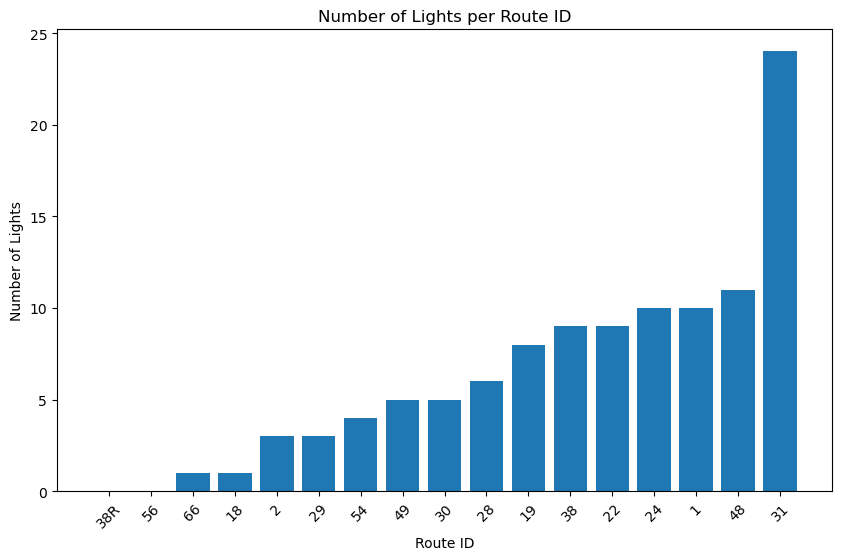

In [139]:
# Plotting the bar chart
plt.figure(figsize=(10, 6))
plt.bar(lights_per_route['route_id'].astype(str), lights_per_route['number_of_lights'])
plt.xlabel('Route ID')
plt.ylabel('Number of Lights')
plt.title('Number of Lights per Route ID')
plt.xticks(rotation=45)
plt.show()

In [88]:

# Count the number of times each unique School Name appears
school_name_counts = merged_df.groupby('School Name').size().reset_index(name='counts')

In [89]:
school_name_counts 

,School Name,counts
0,"Burton, Phillip And Sala Burton High School",5
1,Galileo High School,14
2,Gateway High School / Kipp Sf Bay Academy,13
3,"Lincoln, Abraham Lincoln High School",4
4,"Washington, George Washington High School",20


In [90]:
# Sort the counts in descending order
school_name_counts_sorted = school_name_counts.sort_values(by='counts', ascending=False)

In [91]:
school_name_counts_sorted

,School Name,counts
4,"Washington, George Washington High School",20
1,Galileo High School,14
2,Gateway High School / Kipp Sf Bay Academy,13
0,"Burton, Phillip And Sala Burton High School",5
3,"Lincoln, Abraham Lincoln High School",4


In [149]:
stopcrimes = pd.read_csv('crimey.csv')

In [194]:
stopcrimes

,df_index,df2_index,df_coordinates,df2_coordinates,route_id,school_name
0,8,12,"(37.72872924804688, -122.4312973022461)","(37.728723, -122.43132)",49,Galileo High School
1,12,379,"(37.75231170654297, -122.39651489257812)","(37.752287, -122.396482)",19,Galileo High School
2,81,728,"(37.75130462646485, -122.43408966064452)","(37.751315, -122.43411)",48,"Lincoln, Abraham Lincoln High School"
3,89,61,"(37.7332763671875, -122.39768981933594)","(37.7333, -122.39762)",54,"Burton, Phillip And Sala Burton High School"
4,478,710,"(37.7875680237141, -122.40658988465438)","(37.787633, -122.406568)",38,"Washington, George Washington High School"
...,...,...,...,...,...,...
68,5968,515,"(37.78568649291992, -122.42139434814452)","(37.785647, -122.421368)",49,Galileo High School
69,6368,653,"(37.79217529296875, -122.42269134521484)","(37.792134, -122.422661)",49,Galileo High School
70,6436,350,"(37.71646118164063, -122.4410171508789)","(37.716419, -122.441012)",54,"Burton, Phillip And Sala Burton High School"
71,6632,350,"(37.71646118164063, -122.4410171508789)","(37.716419, -122.441012)",54,"Burton, Phillip And Sala Burton High School"


In [225]:
# Ensure that all route_ids are included, even if there are no lights
all_route_ids2 = pd.Series(df_unique['route_id'])

In [226]:

# Group by route_id and count the number of lights (stops)
crime_per_route = stopcrimes.groupby('route_id').size().reset_index(name='crimes')

In [227]:
crime_per_route

,route_id,crimes
0,19,10
1,22,9
2,24,2
3,31,1
4,38,1
5,48,1
6,49,36
7,54,13


In [229]:
crime_per_route = crime_per_route.sort_values(by='crimes', ascending=True)

In [230]:
crime_per_route

,route_id,crimes
3,31,1
4,38,1
5,48,1
2,24,2
1,22,9
0,19,10
7,54,13
6,49,36


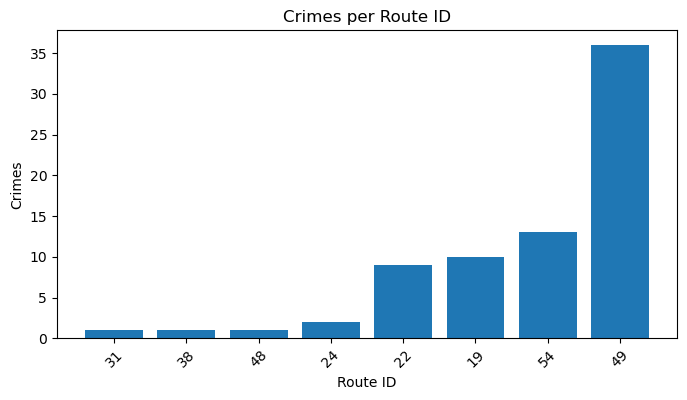

In [238]:
# Plotting the bar chart
plt.figure(figsize=(8, 4))
plt.bar(crime_per_route['route_id'].astype(str), crime_per_route['crimes'])
plt.xlabel('Route ID')
plt.ylabel('Crimes')
plt.title('Crimes per Route ID')
plt.xticks(rotation=45)
plt.show()